In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [10]:
df=pd.read_csv(r"C:\Users\user\rent_prediction\data\raw\cities_magicbricks_rental_prices.csv")


In [3]:
df.head()

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0


In [4]:
df.columns

Index(['house_type', 'locality', 'city', 'area', 'beds', 'bathrooms',
       'balconies', 'furnishing', 'area_rate', 'rent'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   object 
 1   locality    7691 non-null   object 
 2   city        7691 non-null   object 
 3   area        7691 non-null   float64
 4   beds        7691 non-null   int64  
 5   bathrooms   7691 non-null   int64  
 6   balconies   7691 non-null   int64  
 7   furnishing  7691 non-null   object 
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 601.0+ KB


In [6]:
df.describe()

,area,beds,bathrooms,balconies,area_rate,rent
count,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7.691000e+03
mean,1106.354180,2.208685,2.137043,0.817319,47.619989,5.479508e+04
std,1197.426843,0.993481,1.027677,1.243361,68.989657,9.742006e+04
min,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000e+03
25%,600.000000,1.000000,1.000000,0.000000,21.000000,1.500000e+04
50%,900.000000,2.000000,2.000000,0.000000,31.000000,2.800000e+04
75%,1300.000000,3.000000,3.000000,2.000000,54.000000,5.700000e+04
max,70000.000000,10.000000,10.000000,10.000000,2586.000000,2.700000e+06


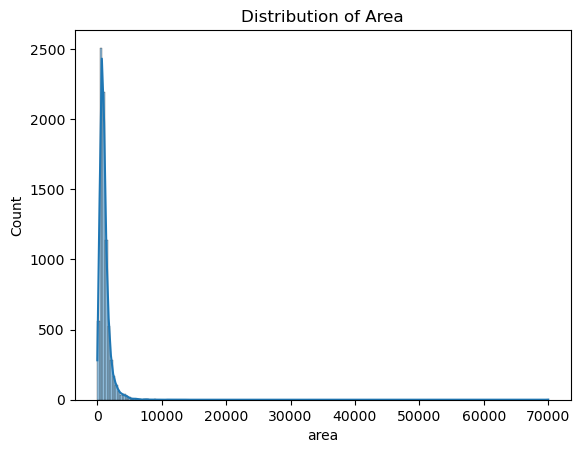

In [7]:
sns.histplot(df['area'],kde=True)
plt.title("Distribution of Area")
plt.show()

In [8]:
#data is right skewed.most of the houses have normal area but some houses have large area

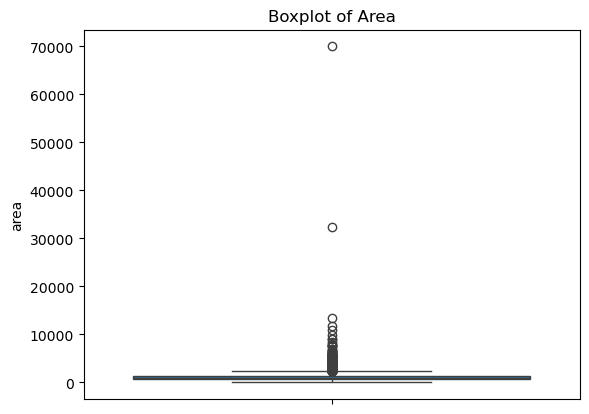

In [9]:
sns.boxplot(df['area'])
plt.title("Boxplot of Area")
plt.show()

In [10]:
#have outliers.due outliers data highly right skewed

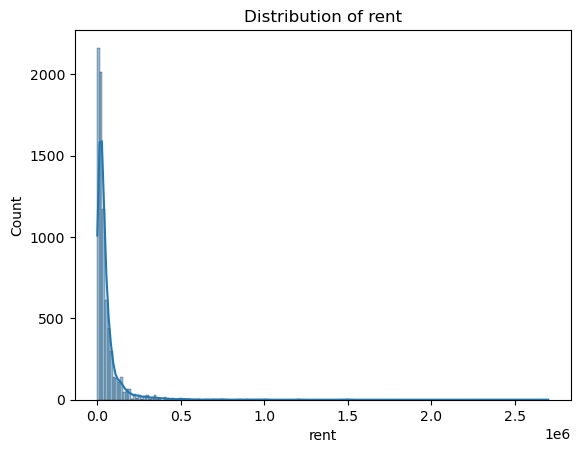

In [11]:
sns.histplot(df['rent'],kde=True)
plt.title("Distribution of rent")
plt.show()

In [12]:
#data is right skewed

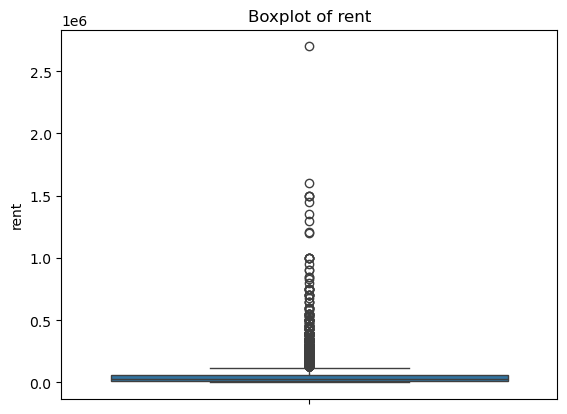

In [13]:
sns.boxplot(df['rent'])
plt.title("Boxplot of rent")
plt.show()

In [14]:
#having outliers having extreme rent for one house.median is closer to lower quartile so data is right skewed

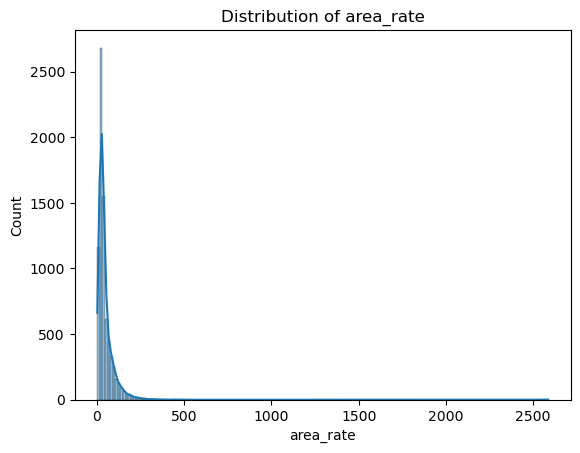

In [15]:
sns.histplot(df['area_rate'],kde=True)
plt.title("Distribution of area_rate")
plt.show()

In [16]:
#data is right skewed

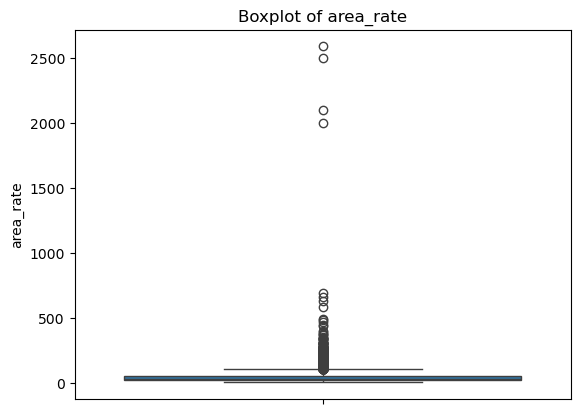

In [17]:
sns.boxplot(df['area_rate'])
plt.title("Boxplot of area_rate")
plt.show()

In [18]:
#most values are in lower area_rate.median is close to lower quartile indicates right skew.many high outliers

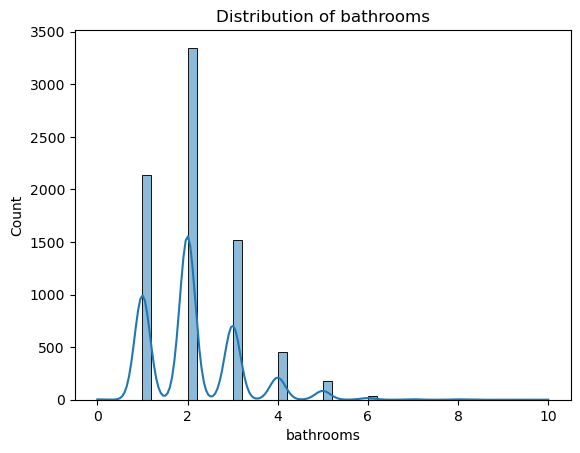

In [19]:
sns.histplot(df['bathrooms'],kde=True)
plt.title("Distribution of bathrooms" )
plt.show()

In [20]:
#most of the houses have 2 bathrooms.some have 10

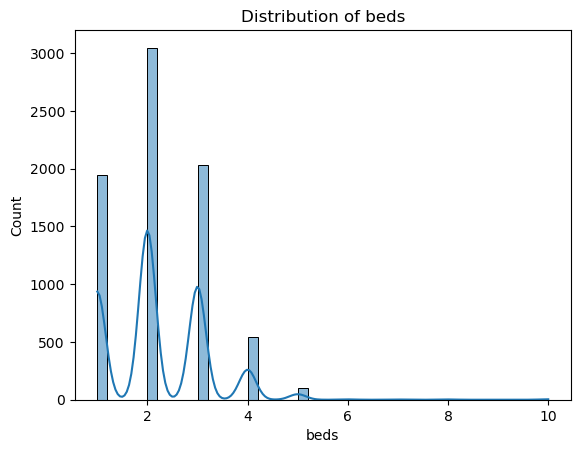

In [21]:
sns.histplot(df['beds'],kde=True)
plt.title("Distribution of beds" )
plt.show()

In [22]:
#most of the houses have 2 beds.some have 10

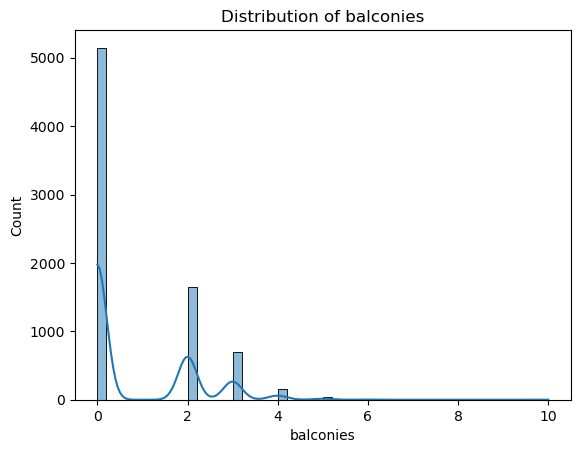

In [23]:
sns.histplot(df['balconies'],kde=True)
plt.title("Distribution of balconies" )
plt.show()

In [24]:
#most of the houses doesnt have balconies

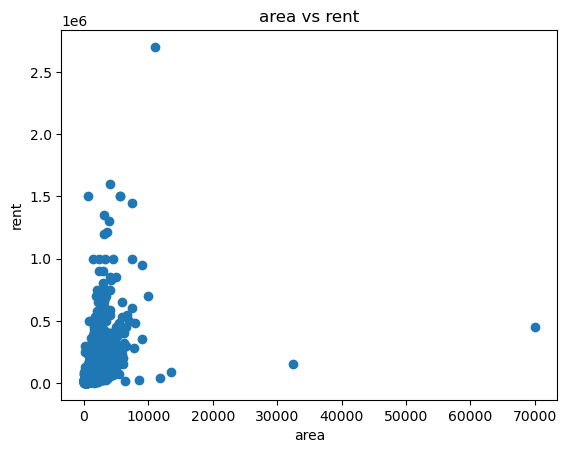

In [25]:
plt.scatter(x=df['area'],y=df['rent'])
plt.xlabel('area')
plt.ylabel('rent')
plt.title('area vs rent')
plt.show()

In [26]:
#as area increase rent also increases,it shows a positive relationship.most of the houses area below 10000.some houses have extremly large area.for similer area of houses have diiferent rent which rent depends other factors also

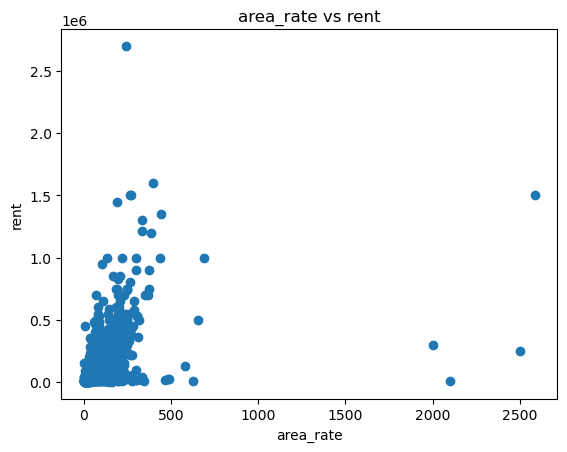

In [27]:
plt.scatter(x=df['area_rate'],y=df['rent'])
plt.xlabel('area_rate')
plt.ylabel('rent')
plt.title('area_rate vs rent')
plt.show()

In [28]:
#area_rate is also increases with rent.which shows positive relationship

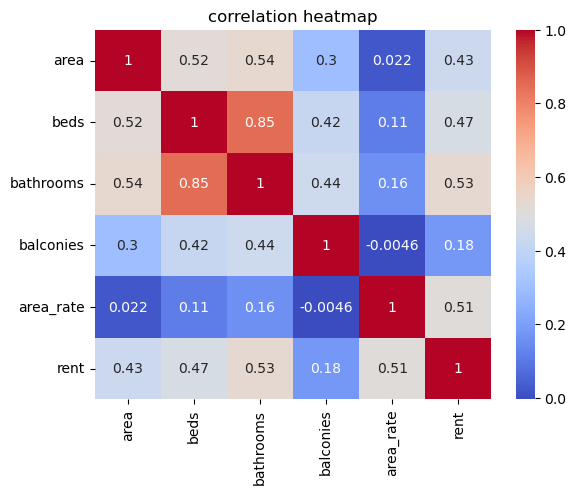

In [29]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("correlation heatmap")
plt.show()

In [30]:
#area,beds,bathrooms,area_rate have moderate positive correlatin with rent and balconnies have negative correlation with rent

In [31]:
X=df.drop('rent',axis=1)
y=df['rent']

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
X_train.head()

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate
4660,"4 BHK Flat for Rent in Stage 1 BTM Layout, Ban...",BTM Layout Stage 1,Bangalore,3300.0,4,4,3,Furnished,29.0
4410,2 BHK Flat for Rent in Chhatrapati Shivaji mah...,Shivaji Park,Mumbai,650.0,2,2,0,Semi-Furnished,146.0
501,"4 BHK Flat for Rent in Cassias Apartment, Band...",Bandra West,Mumbai,2100.0,4,3,4,Semi-Furnished,214.0
2432,1 BHK Flat for Rent in Ashok Nagar Kandivali E...,Ashok Nagar Kandivali East,Mumbai,400.0,1,2,0,Unfurnished,42.0
6922,1 BHK House for Rent in Tulasi Layout Bangalore,Tulasi Layout,Bangalore,450.0,1,1,0,Semi-Furnished,23.0


In [34]:
X_train['BHK']=X_train['house_type'].str.extract('(\d+)').astype(int)
X_test['BHK']=X_test['house_type'].str.extract('(\d+)').astype(int)
X_train['property_type']=X_train['house_type'].str.extract('(Flat|House|Villa)')
X_test['property_type']=X_test['house_type'].str.extract('(Flat|House|Villa)')
X_train.drop('house_type',axis=1,inplace=True)
X_test.drop('house_type',axis=1,inplace=True)

In [35]:
X_train.head()

,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,BHK,property_type
4660,BTM Layout Stage 1,Bangalore,3300.0,4,4,3,Furnished,29.0,4,Flat
4410,Shivaji Park,Mumbai,650.0,2,2,0,Semi-Furnished,146.0,2,Flat
501,Bandra West,Mumbai,2100.0,4,3,4,Semi-Furnished,214.0,4,Flat
2432,Ashok Nagar Kandivali East,Mumbai,400.0,1,2,0,Unfurnished,42.0,1,Flat
6922,Tulasi Layout,Bangalore,450.0,1,1,0,Semi-Furnished,23.0,1,House


In [36]:
from sklearn.preprocessing import OneHotEncoder

In [37]:
encoder=OneHotEncoder(sparse_output=False)
encoded=encoder.fit_transform(X_train[['furnishing']])
cols=encoder.categories_[0]
encoded_df=pd.DataFrame(encoded,columns=cols)
X_train=X_train.reset_index(drop=True)
encoded_df=encoded_df.reset_index(drop=True)
X_train=pd.concat([X_train,encoded_df],axis=1)
X_train=X_train.drop('furnishing',axis=1)

encoded=encoder.transform(X_test[['furnishing']])
cols=encoder.categories_[0]
encoded_df=pd.DataFrame(encoded,columns=cols)
X_test=X_test.reset_index(drop=True)
encoded_df=encoded_df.reset_index(drop=True)
X_test=pd.concat([X_test,encoded_df],axis=1)
X_test=X_test.drop('furnishing',axis=1)

In [38]:
X_train.head()

,locality,city,area,beds,bathrooms,balconies,area_rate,BHK,property_type,Furnished,Semi-Furnished,Unfurnished
0,BTM Layout Stage 1,Bangalore,3300.0,4,4,3,29.0,4,Flat,1.0,0.0,0.0
1,Shivaji Park,Mumbai,650.0,2,2,0,146.0,2,Flat,0.0,1.0,0.0
2,Bandra West,Mumbai,2100.0,4,3,4,214.0,4,Flat,0.0,1.0,0.0
3,Ashok Nagar Kandivali East,Mumbai,400.0,1,2,0,42.0,1,Flat,0.0,0.0,1.0
4,Tulasi Layout,Bangalore,450.0,1,1,0,23.0,1,House,0.0,1.0,0.0


In [39]:
encoder=OneHotEncoder(sparse_output=False)
encoded=encoder.fit_transform(X_train[['property_type']])
cols=encoder.categories_[0]
encoded_df=pd.DataFrame(encoded,columns=cols)
X_train=X_train.reset_index(drop=True)
encoded_df=encoded_df.reset_index(drop=True)
X_train=pd.concat([X_train,encoded_df],axis=1)
X_train=X_train.drop('property_type',axis=1)

encoded=encoder.transform(X_test[['property_type']])
cols=encoder.categories_[0]
encoded_df=pd.DataFrame(encoded,columns=cols)
X_test=X_test.reset_index(drop=True)
encoded_df=encoded_df.reset_index(drop=True)
X_test=pd.concat([X_test,encoded_df],axis=1)
X_test=X_test.drop('property_type',axis=1)

In [40]:
X_train.head()

,locality,city,area,beds,bathrooms,balconies,area_rate,BHK,Furnished,Semi-Furnished,Unfurnished,Flat,House,Villa
0,BTM Layout Stage 1,Bangalore,3300.0,4,4,3,29.0,4,1.0,0.0,0.0,1.0,0.0,0.0
1,Shivaji Park,Mumbai,650.0,2,2,0,146.0,2,0.0,1.0,0.0,1.0,0.0,0.0
2,Bandra West,Mumbai,2100.0,4,3,4,214.0,4,0.0,1.0,0.0,1.0,0.0,0.0
3,Ashok Nagar Kandivali East,Mumbai,400.0,1,2,0,42.0,1,0.0,0.0,1.0,1.0,0.0,0.0
4,Tulasi Layout,Bangalore,450.0,1,1,0,23.0,1,0.0,1.0,0.0,0.0,1.0,0.0


In [41]:
X_train['city'].value_counts()

city
New Delhi    1439
Pune         1434
Bangalore    1420
Mumbai       1380
Nagpur        479
Name: count, dtype: int64

In [42]:
encoder=OneHotEncoder(sparse_output=False)
encoded=encoder.fit_transform(X_train[['city']])
cols=encoder.categories_[0]
encoded_df=pd.DataFrame(encoded,columns=cols)
X_train=X_train.reset_index(drop=True)
encoded_df=encoded_df.reset_index(drop=True)
X_train=pd.concat([X_train,encoded_df],axis=1)
X_train=X_train.drop('city',axis=1)

encoded=encoder.transform(X_test[['city']])
cols=encoder.categories_[0]
encoded_df=pd.DataFrame(encoded,columns=cols)
X_test=X_test.reset_index(drop=True)
encoded_df=encoded_df.reset_index(drop=True)
X_test=pd.concat([X_test,encoded_df],axis=1)
X_test=X_test.drop('city',axis=1)

In [43]:
X_train.head()

,locality,area,beds,bathrooms,balconies,area_rate,BHK,Furnished,Semi-Furnished,Unfurnished,Flat,House,Villa,Bangalore,Mumbai,Nagpur,New Delhi,Pune
0,BTM Layout Stage 1,3300.0,4,4,3,29.0,4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,Shivaji Park,650.0,2,2,0,146.0,2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Bandra West,2100.0,4,3,4,214.0,4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,Ashok Nagar Kandivali East,400.0,1,2,0,42.0,1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,Tulasi Layout,450.0,1,1,0,23.0,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [44]:
locality_mean=y_train.groupby(X_train['locality']).mean()
X_train['locality']=X_train['locality'].map(locality_mean)
X_test['locality']=X_test['locality'].map(locality_mean)
train_mean=y_train.mean()
X_train['locality']=X_train['locality'].fillna(train_mean)
X_test['locality']=X_test['locality'].fillna(train_mean)

In [45]:
X_train.head()

,locality,area,beds,bathrooms,balconies,area_rate,BHK,Furnished,Semi-Furnished,Unfurnished,Flat,House,Villa,Bangalore,Mumbai,Nagpur,New Delhi,Pune
0,79000.000000,3300.0,4,4,3,29.0,4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,64875.000000,650.0,2,2,0,146.0,2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,71611.111111,2100.0,4,3,4,214.0,4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,8000.000000,400.0,1,2,0,42.0,1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,15000.000000,450.0,1,1,0,23.0,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [46]:

X_train['area']=np.log1p(X_train['area'])
X_test['area']=np.log1p(X_test['area'])
X_train['area_rate']=np.log1p(X_train['area_rate'])
X_test['area_rate']=np.log1p(X_test['area_rate'])
y_train=np.log1p(y_train)
y_test=np.log1p(y_test)

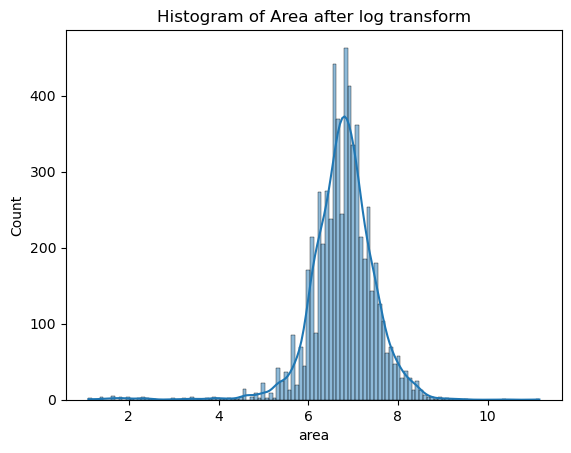

In [47]:
sns.histplot(X_train['area'],kde=True)
plt.title("Histogram of Area after log transform" )
plt.show()

In [48]:
#after log transform skewness is reduced.data is almost look like normal distribution

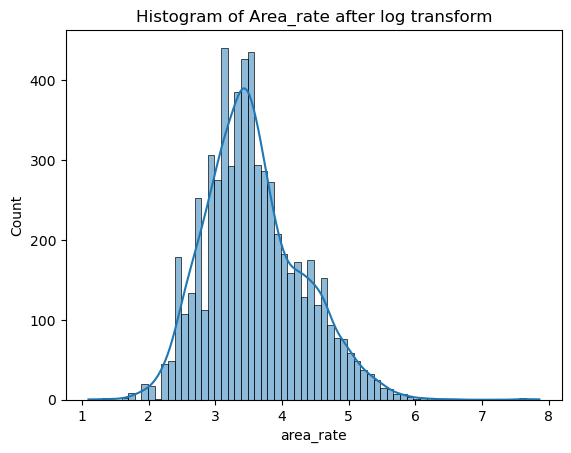

In [49]:
sns.histplot(X_train['area_rate'],kde=True)
plt.title("Histogram of Area_rate after log transform" )
plt.show()

In [50]:
#skewness is reduced

In [51]:
numerical_cols=X_train.select_dtypes(include=['int64','float64']).columns

In [52]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
X_train[numerical_cols]=scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols]=scaler.transform(X_test[numerical_cols])

In [53]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
y_train_pred=lr_model.predict(X_train)
y_test_pred=lr_model.predict(X_test)

In [55]:
from sklearn.metrics import mean_squared_error,r2_score
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

In [56]:
print("Train MSE:",train_mse,"R2:",train_r2)
print("Test MSE:",test_mse,"R2:",test_r2)

Train MSE: 0.05537866805681406 R2: 0.9432715774600158
Test MSE: 0.06668500921423244 R2: 0.9319085006221584


In [57]:
#The model performs well with high R2 score and low MSE values


In [58]:
from sklearn.linear_model import Ridge,Lasso

In [59]:
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
y_train_ridge=ridge.predict(X_train)
y_test_ridge=ridge.predict(X_test)
print("RIDGE REGRESSION")
print("Train MSE:",mean_squared_error(y_train,y_train_ridge))
print("Test MSE:",mean_squared_error(y_test,y_test_ridge))
print("Train R2:",r2_score(y_train,y_train_ridge))
print("Test R2:",r2_score(y_test,y_test_ridge))


RIDGE REGRESSION
Train MSE: 0.055378730737659324
Test MSE: 0.06667416764045389
Train R2: 0.9432715132514387
Test R2: 0.9319195708615254


In [60]:
lasso=Lasso(alpha=0.1)
lasso.fit(X_train,y_train)
y_train_lasso=lasso.predict(X_train)
y_test_lasso=lasso.predict(X_test)
print("LASSO REGRESSION")
print("Train MSE:",mean_squared_error(y_train,y_train_lasso))
print("Test MSE:",mean_squared_error(y_test,y_test_lasso))
print("Train R2:",r2_score(y_train,y_train_lasso))
print("Test R2:",r2_score(y_test,y_test_lasso))


LASSO REGRESSION
Train MSE: 0.10506103101663117
Test MSE: 0.12095478303108688
Train R2: 0.8923782971110208
Test R2: 0.8764940931919308


In [61]:
#based on evaluation metrics,Linear regression performed the best for this dataset with high R2 andlowest MSE
#Ridge regression produced similar results,shows that regularization doesn't needed for this dataset.
#Lasso regression,lower R2 score and higher MSE compared to linear and ridge regression.
#so,Linear regression model is best for this dataset